In [4]:
import kagglehub
from os import getcwd 
import shutil

In [5]:
# path = kagglehub.dataset_download(
#     "orvile/household-energy-consumption-with-weather-data")
# shutil.copytree(path, getcwd(), dirs_exist_ok=True)

In [6]:
import pandas as pd

In [7]:
df = pd.read_csv("energy_weather_raw_data.csv")

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605260 entries, 0 to 605259
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   date            605260 non-null  object 
 1   active_power    605260 non-null  float64
 2   current         605260 non-null  float64
 3   voltage         605260 non-null  float64
 4   reactive_power  605260 non-null  float64
 5   apparent_power  605260 non-null  float64
 6   power_factor    605260 non-null  float64
 7   main            605260 non-null  object 
 8   description     605260 non-null  object 
 9   temp            605260 non-null  float64
 10  feels_like      605260 non-null  float64
 11  temp_min        605260 non-null  float64
 12  temp_max        605260 non-null  float64
 13  pressure        605260 non-null  int64  
 14  humidity        605260 non-null  int64  
 15  speed           605260 non-null  float64
 16  deg             605260 non-null  int64  
 17  temp_t+1  

In [9]:
df.head()

,date,active_power,current,voltage,reactive_power,apparent_power,power_factor,main,description,temp,feels_like,temp_min,temp_max,pressure,humidity,speed,deg,temp_t+1,feels_like_t+1
0,2022-11-05 14:05:00,265.1,2.53,122.2,159.09,309.17,0.8575,Clear,clear sky,24.19,23.68,23.44,27.5,1013,39,0.0,0,29.63,27.97
1,2022-11-05 14:06:00,265.1,2.53,122.2,159.09,309.17,0.8575,Clear,clear sky,24.19,23.68,23.44,27.5,1013,39,0.0,0,29.63,27.97
2,2022-11-05 14:07:00,265.1,2.53,122.2,159.09,309.17,0.8575,Clear,clear sky,24.19,23.68,23.44,27.5,1013,39,0.0,0,29.63,27.97
3,2022-11-05 14:08:00,640.0,5.45,120.7,152.08,657.82,0.9729,Clear,clear sky,24.19,23.68,23.44,27.5,1013,39,0.0,0,29.63,27.97
4,2022-11-05 14:09:00,257.6,2.47,122.4,158.26,302.33,0.8520,Clear,clear sky,24.19,23.68,23.44,27.5,1013,39,0.0,0,29.63,27.97


In [10]:
df.drop(["current", "voltage", "reactive_power", "apparent_power", "power_factor"], axis=1, inplace=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605260 entries, 0 to 605259
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   date            605260 non-null  object 
 1   active_power    605260 non-null  float64
 2   main            605260 non-null  object 
 3   description     605260 non-null  object 
 4   temp            605260 non-null  float64
 5   feels_like      605260 non-null  float64
 6   temp_min        605260 non-null  float64
 7   temp_max        605260 non-null  float64
 8   pressure        605260 non-null  int64  
 9   humidity        605260 non-null  int64  
 10  speed           605260 non-null  float64
 11  deg             605260 non-null  int64  
 12  temp_t+1        605260 non-null  float64
 13  feels_like_t+1  605260 non-null  float64
dtypes: float64(8), int64(3), object(3)
memory usage: 64.6+ MB


In [12]:
df.isnull().sum()

,0
date,0
active_power,0
main,0
description,0
temp,0
feels_like,0
temp_min,0
temp_max,0
pressure,0
humidity,0


In [13]:
df.describe()

,active_power,temp,feels_like,temp_min,temp_max,pressure,humidity,speed,deg,temp_t+1,feels_like_t+1
count,605260.000000,605260.000000,605260.000000,605260.000000,605260.000000,605260.000000,605260.000000,605260.000000,605260.000000,605260.000000,605260.000000
mean,286.019377,19.525256,18.712625,18.086967,20.800759,1015.224680,47.954590,2.622621,152.735540,19.539568,18.728081
std,189.545683,6.607351,6.722516,6.519213,6.351933,5.992024,19.445563,2.093100,127.593552,6.599504,6.714456
min,24.400000,-5.560000,-6.130000,-5.560000,-5.560000,996.000000,1.000000,0.000000,0.000000,-5.560000,-6.130000
25%,159.800000,14.810000,13.900000,13.440000,16.180000,1011.000000,32.000000,1.050000,30.000000,14.810000,13.920000
50%,250.300000,19.490000,18.900000,18.060000,20.440000,1015.000000,47.000000,2.240000,144.000000,19.510000,18.910000
75%,365.400000,24.250000,23.830000,22.590000,25.440000,1019.000000,63.000000,4.120000,248.000000,24.260000,23.850000
max,2900.000000,39.370000,36.700000,37.590000,39.440000,1035.000000,100.000000,10.290000,360.000000,39.370000,36.700000


In [14]:
import matplotlib.pyplot as plt

{'whiskers': [<matplotlib.lines.Line2D at 0x7834a11b5af0>,
 'caps': [<matplotlib.lines.Line2D at 0x7834a11b60f0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7834c4308560>],
 'medians': [<matplotlib.lines.Line2D at 0x7834a11b6660>],
 'fliers': [<matplotlib.lines.Line2D at 0x7834a11b69c0>],
 'means': []}

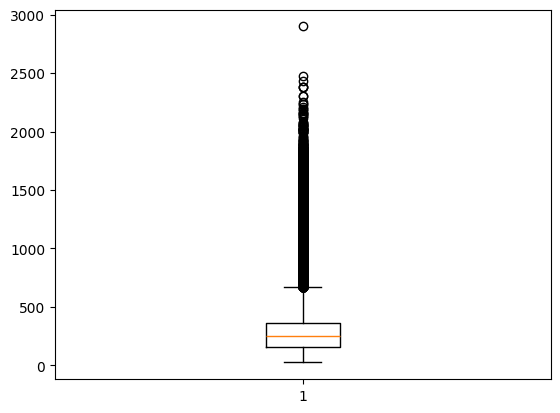

In [15]:
plt.boxplot(df['active_power'])

In [16]:
low, high = df['active_power'].quantile([0.0, 0.8])
# print(low, high)
mask_area = df['active_power'].between(low, high)
df = df[mask_area]

{'whiskers': [<matplotlib.lines.Line2D at 0x7834a55d61b0>,
 'caps': [<matplotlib.lines.Line2D at 0x7834a55d6840>,
 'boxes': [<matplotlib.lines.Line2D at 0x7834a55d5df0>],
 'medians': [<matplotlib.lines.Line2D at 0x7834a55d6ed0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7834a55d71d0>],
 'means': []}

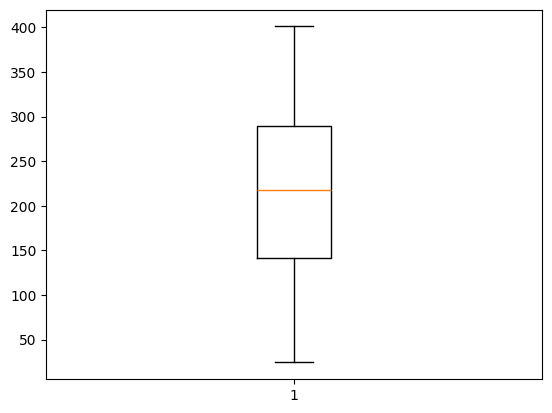

In [17]:
plt.boxplot(df['active_power'])

In [18]:
df["weather"] = df["main"] + " - " +  df["description"]

In [19]:
df.head()

,date,active_power,main,description,temp,feels_like,temp_min,temp_max,pressure,humidity,speed,deg,temp_t+1,feels_like_t+1,weather
0,2022-11-05 14:05:00,265.1,Clear,clear sky,24.19,23.68,23.44,27.5,1013,39,0.0,0,29.63,27.97,Clear - clear sky
1,2022-11-05 14:06:00,265.1,Clear,clear sky,24.19,23.68,23.44,27.5,1013,39,0.0,0,29.63,27.97,Clear - clear sky
2,2022-11-05 14:07:00,265.1,Clear,clear sky,24.19,23.68,23.44,27.5,1013,39,0.0,0,29.63,27.97,Clear - clear sky
4,2022-11-05 14:09:00,257.6,Clear,clear sky,24.19,23.68,23.44,27.5,1013,39,0.0,0,29.63,27.97,Clear - clear sky
5,2022-11-05 14:10:00,257.6,Clear,clear sky,24.19,23.68,23.44,27.5,1013,39,0.0,0,29.63,27.97,Clear - clear sky


In [20]:
df["weather"].value_counts()

,count
weather,
Clear - clear sky,220298
Clouds - overcast clouds,73814
Clouds - broken clouds,73775
Clouds - scattered clouds,64460
Clouds - few clouds,24831
Mist - mist,12013
Fog - fog,8196
Haze - haze,4018
Drizzle - light intensity drizzle,1482


In [21]:
df["date"] = pd.to_datetime(df["date"])

In [22]:
df.drop(["main", "description"], axis=1, inplace = True)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 484376 entries, 0 to 605259
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   date            484376 non-null  datetime64[ns]
 1   active_power    484376 non-null  float64       
 2   temp            484376 non-null  float64       
 3   feels_like      484376 non-null  float64       
 4   temp_min        484376 non-null  float64       
 5   temp_max        484376 non-null  float64       
 6   pressure        484376 non-null  int64         
 7   humidity        484376 non-null  int64         
 8   speed           484376 non-null  float64       
 9   deg             484376 non-null  int64         
 10  temp_t+1        484376 non-null  float64       
 11  feels_like_t+1  484376 non-null  float64       
 12  weather         484376 non-null  object        
dtypes: datetime64[ns](1), float64(8), int64(3), object(1)
memory usage: 51.7+ MB


In [24]:
df["date"].is_monotonic_increasing

True

In [25]:
df["date"].duplicated().sum()

np.int64(3)

In [26]:
duplicates = df[df["date"].duplicated(keep=False)]
duplicates.sort_values("date")

,date,active_power,temp,feels_like,temp_min,temp_max,pressure,humidity,speed,deg,temp_t+1,feels_like_t+1,weather
5123,2022-11-09 03:36:00,179.4,14.25,13.58,14.25,14.25,1016,71,2.05,148,14.81,13.86,Clear - clear sky
5124,2022-11-09 03:36:00,179.4,14.25,13.58,14.25,14.25,1016,71,2.05,148,14.81,13.86,Clear - clear sky
5882,2022-11-09 16:16:00,265.0,25.09,24.78,24.81,26.95,1018,43,6.17,340,22.81,22.50,Clear - clear sky
5883,2022-11-09 16:16:00,265.0,25.09,24.78,24.81,26.95,1018,43,6.17,340,22.81,22.50,Clear - clear sky
373862,2023-07-26 13:08:00,229.2,29.01,28.07,27.44,30.36,1019,33,3.09,30,28.12,27.84,Clouds - scattered clouds
373863,2023-07-26 13:08:00,229.2,29.31,28.34,27.44,30.92,1019,33,3.09,30,28.12,27.84,Clouds - scattered clouds


In [27]:
df = df.drop_duplicates(subset="date", keep="first")

In [28]:
df["date"].duplicated().sum()

np.int64(0)

In [29]:
df["date"].diff().value_counts().head()


,count
date,
0 days 00:01:00,470174
0 days 00:02:00,7045
0 days 00:03:00,2710
0 days 00:04:00,884
0 days 00:05:00,454


In [30]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["hour"] = df["date"].dt.hour
df["minute"] = df["date"].dt.minute
df["day_of_week"] = df["date"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

In [31]:
df["lag_1"] = df["active_power"].shift(1)
df["lag_60"] = df["active_power"].shift(60)
df["lag_1440"] = df["active_power"].shift(1440)

In [32]:
df.head(100)

,date,active_power,temp,feels_like,temp_min,temp_max,pressure,humidity,speed,deg,...,year,month,day,hour,minute,day_of_week,is_weekend,lag_1,lag_60,lag_1440
0,2022-11-05 14:05:00,265.1,24.19,23.68,23.44,27.50,1013,39,0.00,0,...,2022,11,5,14,5,5,1,NaN,NaN,NaN
1,2022-11-05 14:06:00,265.1,24.19,23.68,23.44,27.50,1013,39,0.00,0,...,2022,11,5,14,6,5,1,265.1,NaN,NaN
2,2022-11-05 14:07:00,265.1,24.19,23.68,23.44,27.50,1013,39,0.00,0,...,2022,11,5,14,7,5,1,265.1,NaN,NaN
4,2022-11-05 14:09:00,257.6,24.19,23.68,23.44,27.50,1013,39,0.00,0,...,2022,11,5,14,9,5,1,265.1,NaN,NaN
5,2022-11-05 14:10:00,257.6,24.19,23.68,23.44,27.50,1013,39,0.00,0,...,2022,11,5,14,10,5,1,257.6,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,2022-11-05 15:46:00,168.0,24.35,23.81,24.25,27.67,1012,37,3.09,360,...,2022,11,5,15,46,5,1,168.0,173.0,NaN
102,2022-11-05 15:47:00,168.0,24.35,23.81,24.25,27.67,1012,37,3.09,360,...,2022,11,5,15,47,5,1,168.0,173.0,NaN
103,2022-11-05 15:48:00,168.0,24.35,23.81,24.25,27.67,1012,37,3.09,360,...,2022,11,5,15,48,5,1,168.0,173.0,NaN
104,2022-11-05 15:49:00,168.0,24.35,23.81,24.25,27.67,1012,37,3.09,360,...,2022,11,5,15,49,5,1,168.0,173.0,NaN


In [33]:
df = df.dropna().reset_index(drop=True)

In [34]:
x = df.drop(columns=["active_power", "date"])
y = df["active_power"]

In [35]:
x.head()

,temp,feels_like,temp_min,temp_max,pressure,humidity,speed,deg,temp_t+1,feels_like_t+1,...,year,month,day,hour,minute,day_of_week,is_weekend,lag_1,lag_60,lag_1440
0,21.46,20.50,17.52,21.48,1015,32,4.12,360,19.48,18.58,...,2022,11,6,19,37,6,1,384.5,262.3,265.1
1,21.46,20.50,17.52,21.48,1015,32,4.12,360,19.48,18.58,...,2022,11,6,19,38,6,1,384.5,334.4,265.1
2,21.46,20.50,17.52,21.48,1015,32,4.12,360,19.48,18.58,...,2022,11,6,19,39,6,1,384.5,334.4,265.1
3,21.46,20.50,17.52,21.48,1015,32,4.12,360,19.48,18.58,...,2022,11,6,19,40,6,1,384.5,334.4,257.6
4,20.85,19.88,17.52,21.44,1015,34,4.12,360,19.48,18.58,...,2022,11,6,19,41,6,1,384.5,334.4,257.6


In [36]:
y.head()

,active_power
0,384.5
1,384.5
2,384.5
3,384.5
4,384.5


In [37]:
train_end = int(len(df) * 0.70)
val_end = int(len(df) * 0.85)

x_train = x.iloc[:train_end]
x_val = x.iloc[train_end:val_end]
x_test = x.iloc[val_end:]

y_train = y.iloc[:train_end]
y_val = y.iloc[train_end:val_end]
y_test = y.iloc[val_end:]

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [39]:
categorical_features = ["weather"]

numerical_features = (
    x_train
    .select_dtypes(include=["number"])
    .columns
    .tolist()
)

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numerical_features)
    ]
)

In [41]:
x_train_processed = preprocessor.fit_transform(x_train)
x_val_processed = preprocessor.transform(x_val)
x_test_processed = preprocessor.transform(x_test)

In [42]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train_processed, y_train)

LinearRegression()

In [43]:
y_train_pred = model.predict(x_train_processed)
y_val_pred = model.predict(x_val_processed)

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [45]:
print("Validation MAE :", mean_absolute_error(y_val, y_val_pred))
print("Validation RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))
print("Validation R²  :", r2_score(y_val, y_val_pred))

Validation MAE : 14.354540147466471
Validation RMSE: 36.57672939188142
Validation R²  : 0.865370292859357


In [46]:
from sklearn.ensemble import RandomForestRegressor

In [47]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train_processed, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [48]:
y_train_pred = rf.predict(x_train_processed)
y_val_pred = rf.predict(x_val_processed)

In [49]:
print("Validation MAE :", mean_absolute_error(y_val, y_val_pred))
print("Validation RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))
print("Validation R²  :", r2_score(y_val, y_val_pred))

Validation MAE : 27.243018208172295
Validation RMSE: 41.68829222398359
Validation R²  : 0.8251122576203451


In [53]:
y_test_pred = rf.predict(x_test_processed)

In [54]:
print("Testing MAE :", mean_absolute_error(y_test, y_test_pred))
print("Testing RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("Testing R²  :", r2_score(y_test, y_test_pred))

Testing MAE : 28.323182495858646
Testing RMSE: 42.93258430243175
Testing R²  : 0.8023547533660671
